In [ ]:
# NumPy is used for numerical operations and reproducible random values.
import numpy as np
# Pandas is used to load and manipulate the applicant dataset.
import pandas as pd
# Matplotlib is used to display model evaluation plots.
import matplotlib.pyplot as plt
# Pickle is used to save the trained model pipeline as a .pkl file.
import pickle
# os is used to create folders and construct local Colab file paths.
import os

In [ ]:
# Utilities required for splitting data, preprocessing features, training,
# evaluating, and displaying the machine-learning model.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler # check this
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, RocCurveDisplay


In [ ]:
# Fix the random seed so that model training and data splitting are reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import files
import io

print("Please upload the dataset file: ")

uploaded = files.upload()

# Get the uploaded file name
dataset_file = next(iter(uploaded))

# Read the uploaded CSV file
df = pd.read_csv(io.BytesIO(uploaded[dataset_file]))

print("\nDataset uploaded successfully.")
print("File name:", dataset_file)
print("Dataset shape:", df.shape)

df.head()

Please upload the dataset file: 


Saving tn_synthetic_aid_dataset.csv to tn_synthetic_aid_dataset.csv

Dataset uploaded successfully.
File name: tn_synthetic_aid_dataset.csv
Dataset shape: (6000, 18)


,district,category,urban,family_income,first_gen,parent_grad,cutoff_12th,entrance_score,college_tier,tuition,distance_km,competing_offers,merit_aid_pct,need_aid_pct,total_aid_pct,aid_amount,net_price,enrolled
0,Coimbatore,SC,1,691000.0,0,1,92.35,145.6,Tier-2 (Affiliated),110000.0,29.8,3,0.443,0.430,0.437,48000.0,62000.0,1
1,Nagapattinam,MBC,0,686000.0,1,0,77.63,130.7,Tier-3 (Self-financing),91000.0,15.8,0,0.389,0.324,0.357,32500.0,58500.0,1
2,Cuddalore,BC,1,579000.0,0,1,68.22,104.2,Tier-2 (Affiliated),108000.0,66.9,0,0.292,0.422,0.357,38500.0,69500.0,1
3,Thanjavur,SC,0,99000.0,0,0,80.98,129.6,Tier-3 (Self-financing),91000.0,31.2,1,0.504,0.457,0.481,43800.0,47200.0,0
4,Thanjavur,OC,0,1034000.0,1,0,77.28,126.9,Tier-2 (Affiliated),119000.0,19.4,2,0.395,0.389,0.392,46600.0,72400.0,0


In [ ]:
# Define the default Colab runtime path.
# Files stored in /content are available during the current Colab session.
MODEL_DIR = '/content'

# Define the paths for the input dataset, trained model, and holdout test set.
#/content/tn_synthetic_aid_dataset.csv
#DATA_PATH = os.path.join(MODEL_DIR, 'tn_synthetic_aid_dataset.csv')
MODEL_PATH = os.path.join(MODEL_DIR, 'yield_model_pipeline.pkl')
HOLDOUT_PATH = os.path.join(MODEL_DIR, 'yield_test_holdout.csv')

In [ ]:
# Define the target column that the model will learn to predict.
target = "enrolled"

# Numerical features used by the model.
num_feats = ["urban", "family_income", "first_gen", "parent_grad", "cutoff_12th", "entrance_score",
             "tuition", "distance_km", "competing_offers", "merit_aid_pct", "need_aid_pct",
             "total_aid_pct", "aid_amount", "net_price"]

# Categorical features used by the model.
cat_feats = ["district", "category", "college_tier"]

In [ ]:
# Select the input features and target values from the loaded dataset.
X = df[num_feats + cat_feats]
y = df[target]

# Split the data into 80% training data and 20% testing data.
# Stratification keeps the enrolled/non-enrolled class distribution similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (4800, 17) | Test: (1200, 17)


In [ ]:
# Preprocess numerical and categorical features separately.
preprocessor = ColumnTransformer([
    # StandardScaler puts numerical features on a comparable scale.
    ("num", StandardScaler(), num_feats),
    # OneHotEncoder converts categorical values into machine-readable binary columns.
    # handle_unknown='ignore' prevents errors when a new category appears during inference.
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
])

# Create one complete pipeline containing preprocessing followed by the classifier.
yield_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        # Use 300 decision trees to build the Random Forest ensemble.
        n_estimators=300,
        # Limit tree depth to reduce unnecessary complexity.
        max_depth=10,
        # Require at least five samples in each leaf for more stable predictions.
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        # Use all available CPU cores for faster training.
        n_jobs=-1
    )),
])

In [ ]:
# Train the complete preprocessing + Random Forest pipeline using the training data.
yield_model.fit(X_train, y_train)
print('Trained.')

Trained.


In [ ]:
# Generate the probability that each test applicant will enroll.
proba = yield_model.predict_proba(X_test)[:, 1]

# Convert probabilities into binary predictions using a 0.5 decision threshold.
pred = (proba >= 0.5).astype(int)

# Calculate classification accuracy and ROC-AUC to evaluate model performance.
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC:  {auc:.3f}")

# Display precision, recall, and F1-score for both enrollment classes.
print(classification_report(y_test, pred, target_names=['Did not enroll', 'Enrolled']))

Accuracy: 0.653
ROC-AUC:  0.702
                precision    recall  f1-score   support

Did not enroll       0.64      0.47      0.54       525
      Enrolled       0.66      0.80      0.72       675

      accuracy                           0.65      1200
     macro avg       0.65      0.63      0.63      1200
  weighted avg       0.65      0.65      0.64      1200



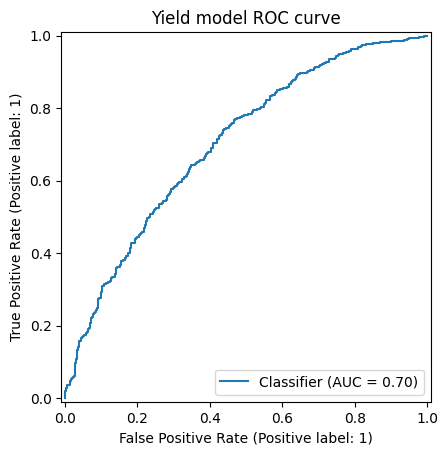

In [ ]:
# Plot the ROC curve to visualize the model's ability to distinguish the two classes.
RocCurveDisplay.from_predictions(y_test, proba)
plt.title('Yield model ROC curve')
plt.show()

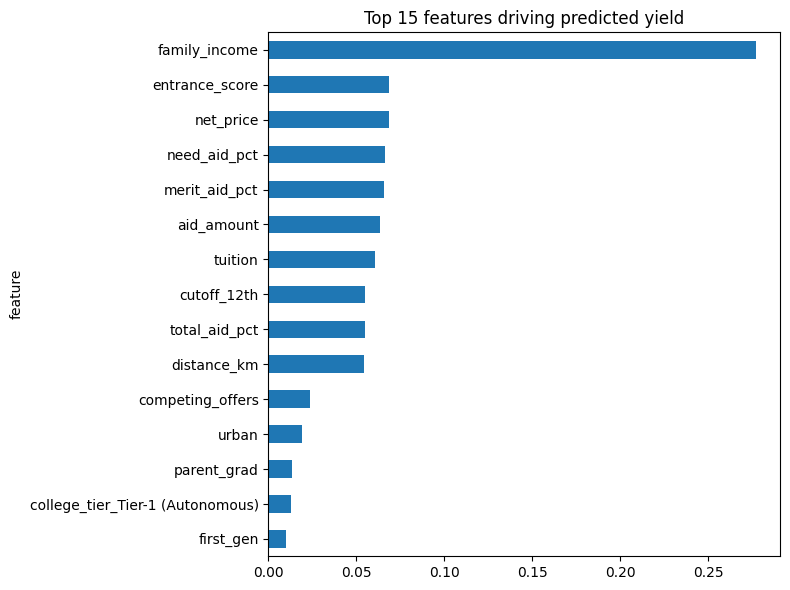

In [ ]:
# Extract the fitted one-hot encoder from the trained preprocessing pipeline.
ohe = yield_model.named_steps['preprocessor'].named_transformers_['cat']

# Combine numerical feature names with the generated one-hot categorical feature names.
feature_names = num_feats + list(ohe.get_feature_names_out(cat_feats))

# Retrieve the Random Forest feature-importance values.
importances = yield_model.named_steps['classifier'].feature_importances_

# Create a table and select the 15 features with the largest importance values.
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

# Plot the top 15 features to show which inputs contributed most to the trained model.
imp_df.plot(kind='barh', x='feature', y='importance', figsize=(8, 6), legend=False, title='Top 15 features driving predicted yield')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Store the trained pipeline and the feature configuration in one dictionary.
bundle = {
    'pipeline': yield_model,
    'num_feats': num_feats,
    'cat_feats': cat_feats,
    'target': target,
    'trained_on': df,
    'metrics': {'accuracy': float(acc), 'roc_auc': float(auc)},
    'notes': 'Pipeline includes preprocessing; feed it raw applicant rows with columns = num_feats + cat_feats.'
}

# Serialize the trained model bundle to a local Colab .pkl file.
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(bundle, f)
print('Model saved ->', MODEL_PATH)

# Save the held-out test data for the testing notebook.
holdout_df = X_test.copy()
holdout_df[target] = y_test.values
holdout_df.to_csv(HOLDOUT_PATH, index=False)
print('Held-out test set saved ->', HOLDOUT_PATH)

Model saved -> /content/yield_model_pipeline.pkl
Held-out test set saved -> /content/yield_test_holdout.csv


# **US Dataset ML Model**

In [ ]:
# Install XGBoost in case this Colab runtime doesn't already have it
!pip install -q xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from xgboost import XGBClassifier

import pickle
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [ ]:
from google.colab import files
import io

print("Please upload the dataset file: ")

uploaded = files.upload()

# Get the uploaded file name
dataset_file = next(iter(uploaded))

# Read the uploaded CSV file
df = pd.read_csv(io.BytesIO(uploaded[dataset_file]))

print("\nDataset uploaded successfully.")
print("File name:", dataset_file)
print("Dataset shape:", df.shape)

df.head()

Please upload the dataset file: 


Saving financial_aid_yield_dataset_model_ready.csv to financial_aid_yield_dataset_model_ready.csv

Dataset uploaded successfully.
File name: financial_aid_yield_dataset_model_ready.csv
Dataset shape: (6000, 24)


,is_in_state,student_aid_index,adjusted_gross_income,first_gen,pell_eligible,hs_gpa,sat_act_percentile,institutional_tier,cost_of_attendance,miles_from_campus,...,need_grant_amt,net_price,enrolled,net_price_to_income_ratio,financial_aid_discount_rate,unmet_financial_need_gap,engagement_velocity,urban_centric_locale_Rural,urban_centric_locale_Suburb,urban_centric_locale_Town
0,0,47307.0,206264.0,0,0,3.61,70.0,1,50454.0,169.8,...,820.0,27342.0,1,0.124516,0.4581,0.0,0.2286,0,1,0
1,1,3408.0,28634.0,0,1,3.82,93.0,0,18794.0,10.3,...,8103.0,9287.0,1,0.280884,0.5059,5879.0,0.0470,0,0,0
2,0,4787.0,35389.0,0,1,3.14,65.0,3,84829.0,82.8,...,33635.0,27407.0,1,0.573462,0.6769,22620.0,0.0079,0,1,0
3,0,10077.0,40054.0,1,0,2.37,41.0,1,53197.0,64.8,...,6499.0,31364.0,0,0.578297,0.4104,21287.0,0.0759,0,0,0
4,0,16174.0,46827.0,0,0,2.12,32.0,0,20468.0,45.0,...,803.0,16901.0,0,0.308146,0.1743,727.0,0.0775,0,0,0


In [ ]:
TARGET_COL = "enrolled"
print("Shape:", df.shape)
print("Target column:", TARGET_COL)
print("Target distribution:")
print(df[TARGET_COL].value_counts())
print("\nMissing values in sat_act_percentile:", df["sat_act_percentile"].isna().sum())

Shape: (6000, 24)
Target column: enrolled
Target distribution:
enrolled
1    3095
0    2905
Name: count, dtype: int64

Missing values in sat_act_percentile: 150


In [ ]:
# The dataset has already been processed by `build_model_ready_dataset()`:
# - `institutional_tier` has been converted to numeric values.
# - `urban_centric_locale` has already been one-hot encoded.
# Therefore, no additional categorical encoding is needed in this training notebook.
# XGBoost can use the remaining numeric/binary columns directly and natively handles
# the NaNs present in `sat_act_percentile`.

CATEGORICAL_FEATURES = []

NUMERICAL_FEATURES = [
    c for c in df.columns
    if c != TARGET_COL
]

In [ ]:
X = df[CATEGORICAL_FEATURES + NUMERICAL_FEATURES]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,   # keep the enrolled/declined ratio consistent across splits
)

In [ ]:
# The data is already model-ready, so no additional one-hot encoding is required.
# All predictor columns are numeric/binary and are passed directly to XGBoost.
# XGBoost is tree-based, so feature scaling is not required.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERICAL_FEATURES),
    ],
    remainder="drop",
)

xgb_classifier = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_classifier),
])

pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['is_in_state',
                                                   'student_aid_index',
                                                   'adjusted_gross_income',
                                                   'first_gen', 'pell_eligible',
                                                   'hs_gpa',
                                                   'sat_act_percentile',
                                                   'institutional_tier',
                                                   'cost_of_attendance',
                                                   'miles_from_campus',
                                                   'fafsa_month_sin',
                                                   'fafsa_month_cos',
                                                   'demonstrated_interest',
                                                   'merit_scholarship_amt',
                                                   'n...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
pipeline.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [ ]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

Accuracy : 0.6358
Precision: 0.6296
Recall   : 0.7141
F1-score : 0.6692
ROC-AUC  : 0.6765


In [ ]:
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Declined (0)", "Enrolled (1)"]))

Classification Report
              precision    recall  f1-score   support

Declined (0)       0.64      0.55      0.59       581
Enrolled (1)       0.63      0.71      0.67       619

    accuracy                           0.64      1200
   macro avg       0.64      0.63      0.63      1200
weighted avg       0.64      0.64      0.63      1200



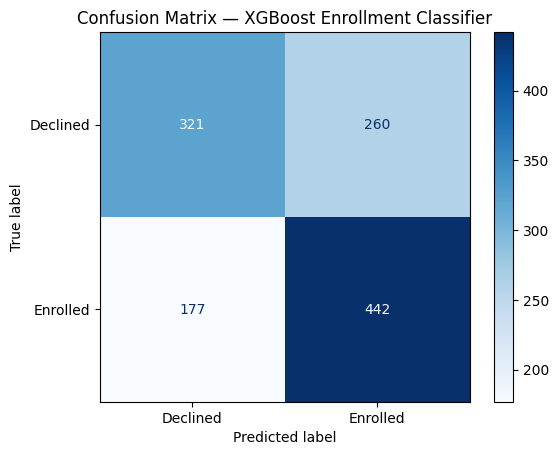

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Declined", "Enrolled"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost Enrollment Classifier")
plt.show()

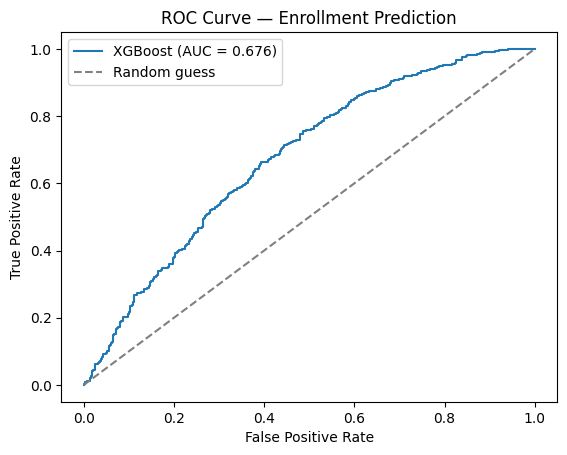

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Enrollment Prediction")
plt.legend()
plt.show()

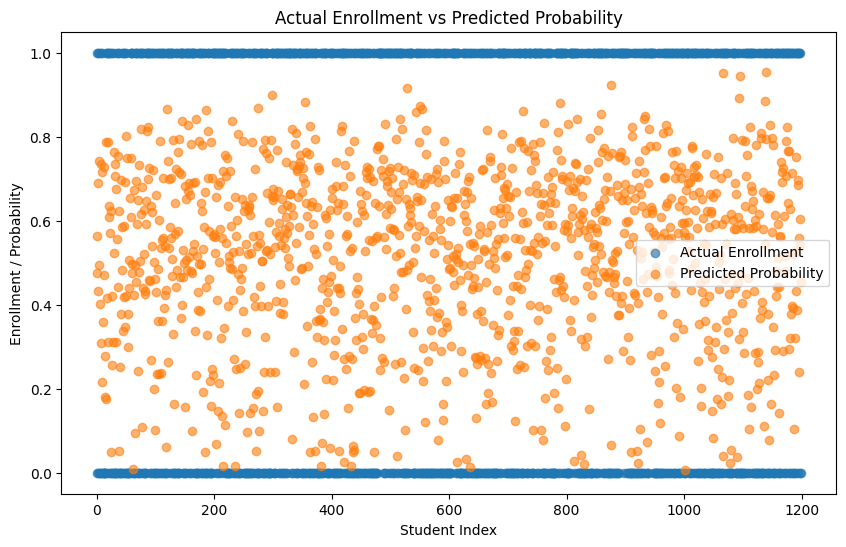

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test)), y_test,
            label="Actual Enrollment", alpha=0.6)

plt.scatter(range(len(y_proba)), y_proba,
            label="Predicted Probability", alpha=0.6)

plt.xlabel("Student Index")
plt.ylabel("Enrollment / Probability")
plt.title("Actual Enrollment vs Predicted Probability")
plt.legend()
plt.show()

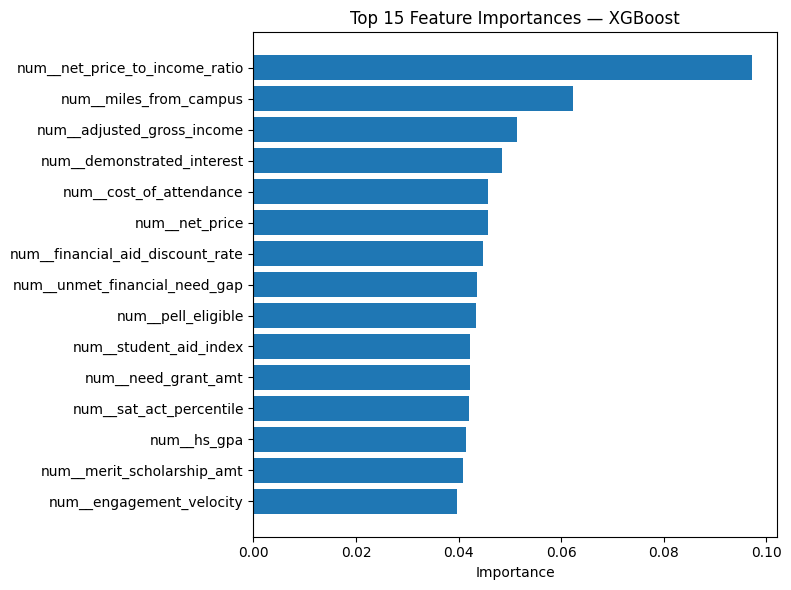

,feature,importance
16,num__net_price_to_income_ratio,0.097112
9,num__miles_from_campus,0.062305
2,num__adjusted_gross_income,0.051305
12,num__demonstrated_interest,0.048393
8,num__cost_of_attendance,0.045746
15,num__net_price,0.045722
17,num__financial_aid_discount_rate,0.044736
18,num__unmet_financial_need_gap,0.043651
4,num__pell_eligible,0.043432
1,num__student_aid_index,0.042288


In [ ]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

importance_df

In [ ]:
MODEL_PATH = "yield_model_pipeline.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Saved trained pipeline to {MODEL_PATH}")

Saved trained pipeline to yield_model_pipeline.pkl


In [ ]:
files.download(MODEL_PATH)